In [39]:
import torch
import open_clip
from PIL import Image
import os
from tqdm.auto import tqdm
import numpy as np

In [30]:
DATA_DIR = '../data/sticker_suggest/'
def filepath(filename):
    return os.path.join(DATA_DIR, filename) 

In [31]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [32]:
model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-L-14", pretrained="openai")

/Users/dlifantyev/prsnl/sticker-suggest/.venv/lib/python3.11/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [33]:
model.to(device)

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-23): 24 x ResidualAttentionBlock(
          (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((1024,), eps=1e-05, elementwi

In [34]:
tokenizer = open_clip.get_tokenizer("ViT-L-14")

In [12]:
sample_img = Image.open(filepath("5764992584032194316.png"))

In [13]:
image = preprocess(sample_img).unsqueeze(0).to(device)

texts = ["ohh thats so nice", "emoji sticker", "it was a rainy day in London"]

In [35]:
def similarity(model, text, image, raw_image):
    print(f"Similarity between '{text}' and the image:")
    display(raw_image)
    
    text_tokens = tokenizer([text]).to(device)

    with torch.no_grad():
        image_features = model.encode_image(image)
        text_features = model.encode_text(text_tokens)

    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    similarity = text_features @ image_features.T
    print(f"{similarity=}")

Similarity between 'ohh thats so nice' and the image:


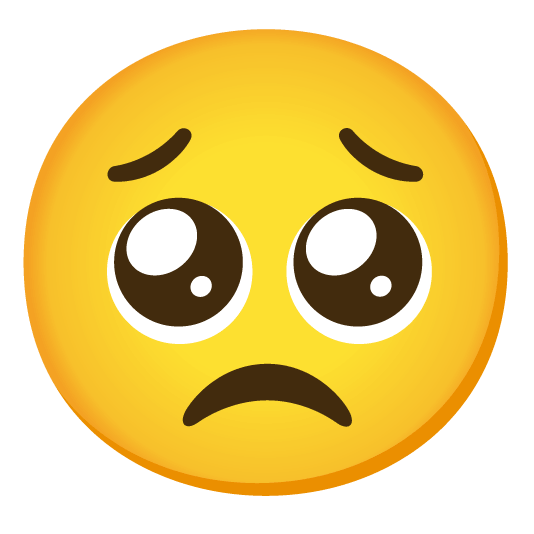

similarity=tensor([[0.1607]], device='mps:0')
Similarity between 'emoji sticker' and the image:


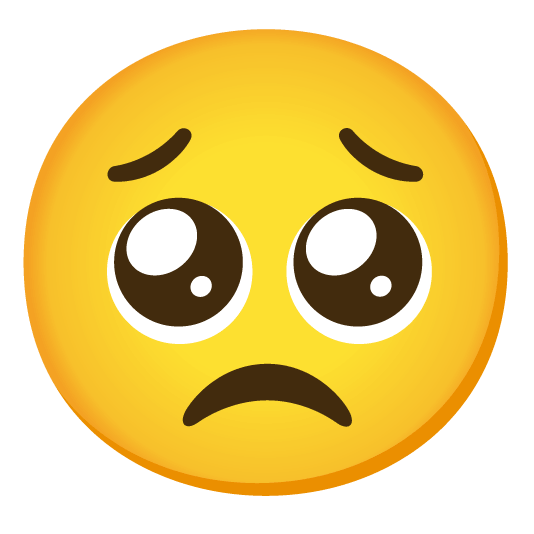

similarity=tensor([[0.2090]], device='mps:0')
Similarity between 'it was a rainy day in London' and the image:


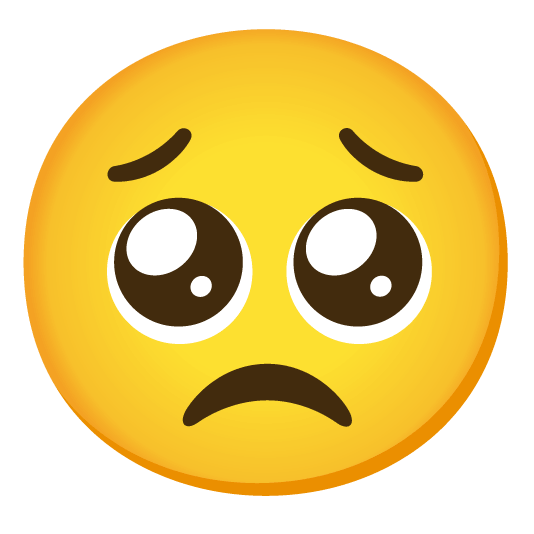

similarity=tensor([[0.1343]], device='mps:0')


In [18]:
for text in texts:
    similarity(model, text, image, sample_img)

Similarity between 'animated character stitch' and the image:


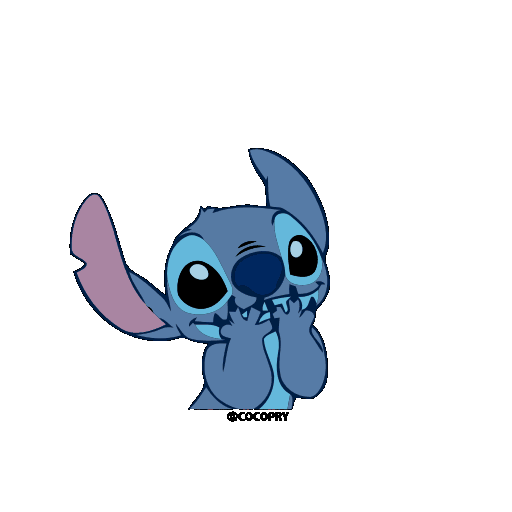

similarity=tensor([[0.2916]], device='mps:0')


In [26]:
sample_gif = Image.open(filepath("1220028319907447512.gif"))
gif = preprocess(sample_gif).unsqueeze(0).to(device)

similarity(model, "animated character stitch", gif, sample_gif)

In [38]:
image_paths = [
    filepath(f) for f in os.listdir(DATA_DIR)
]

embeddings = []

for path in tqdm(image_paths):
    try:
        img = preprocess(Image.open(path)).unsqueeze(0).to(device)
        
        with torch.no_grad():
            emb = model.encode_image(img)
            emb /= emb.norm(dim=-1, keepdim=True)

        embeddings.append(emb.cpu())
        
    except Exception as e:
        print(f"error: {path}")

embeddings = torch.cat(embeddings)

100%|██████████| 9848/9848 [41:26<00:00,  3.96it/s]


In [40]:
np.save("../data/embeddings.npy", embeddings.numpy())
np.save("../data/paths.npy", np.array(image_paths))

In [43]:
embeddings = torch.tensor(np.load("../data/embeddings.npy")).to(device)
paths = np.load("../data/paths.npy")

def search(query, top_k=5):
    text = tokenizer([query]).to(device)

    with torch.no_grad():
        text_emb = model.encode_text(text)
        text_emb /= text_emb.norm(dim=-1, keepdim=True)

    scores = (text_emb @ embeddings.T).squeeze(0)

    top_idx = scores.topk(top_k).indices
    return [(paths[i], scores[i].item()) for i in top_idx]


def show_results(results):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    for i, (path, score) in enumerate(results):
        img = Image.open(path)
        plt.subplot(1, len(results), i + 1)
        plt.imshow(img)
        plt.title(f"{score:.2f}")
        plt.axis("off")

    plt.show()

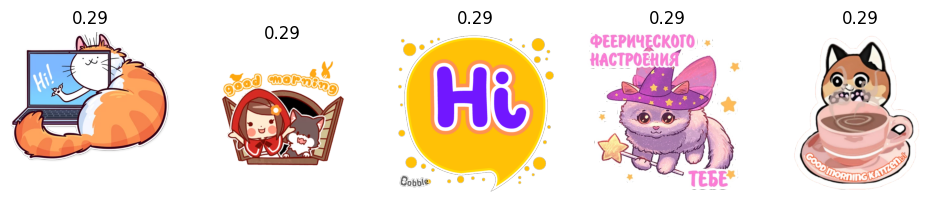

In [ ]:
results = search("cute cat sticker with text hello")
show_results(results)

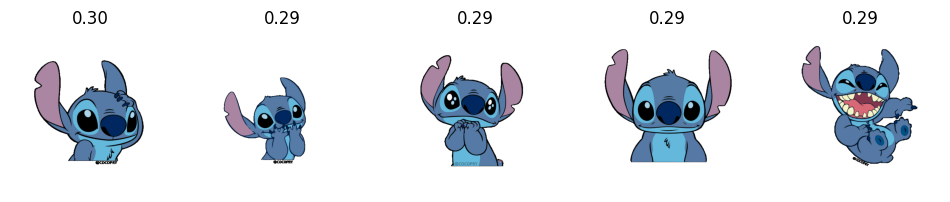

In [49]:
results = search("animated character stitch")
show_results(results)

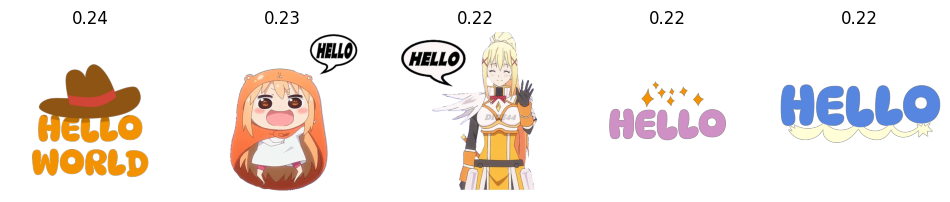

['../data/sticker_suggest/6224412105970288629.png', '../data/sticker_suggest/202331403893872726.png', '../data/sticker_suggest/5929419849271877741.png', '../data/sticker_suggest/6021866645201361172.png', '../data/sticker_suggest/6332410106600231736.png']


In [55]:
results = search("hello world")
show_results(results)
print([str(p) for p, _ in results])